# Bar 차트

In [60]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import matplotlib
import matplotlib.font_manager as fm



In [61]:
# 기본적인 설정
plt.rcParams["figure.figsize"] = [10,8]
sns.set_theme(style="whitegrid")
warnings.filterwarnings("ignore")
plt.rcParams['axes.unicode_minus'] = False

### 기본제공하는 tips dataset 불러오기

In [62]:
tips = sns.load_dataset("tips")
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [63]:
sum_tip_by_day = tips.groupby("day")["tip"].sum()
sum_tip_by_day

day
Thur    171.83
Fri      51.96
Sat     260.40
Sun     247.39
Name: tip, dtype: float64

In [64]:
x_label = ["Thu","Fri","Sat","Sun"]
x_label_index = np.arange(len(x_label))
x_label_index

array([0, 1, 2, 3])

<BarContainer object of 4 artists>

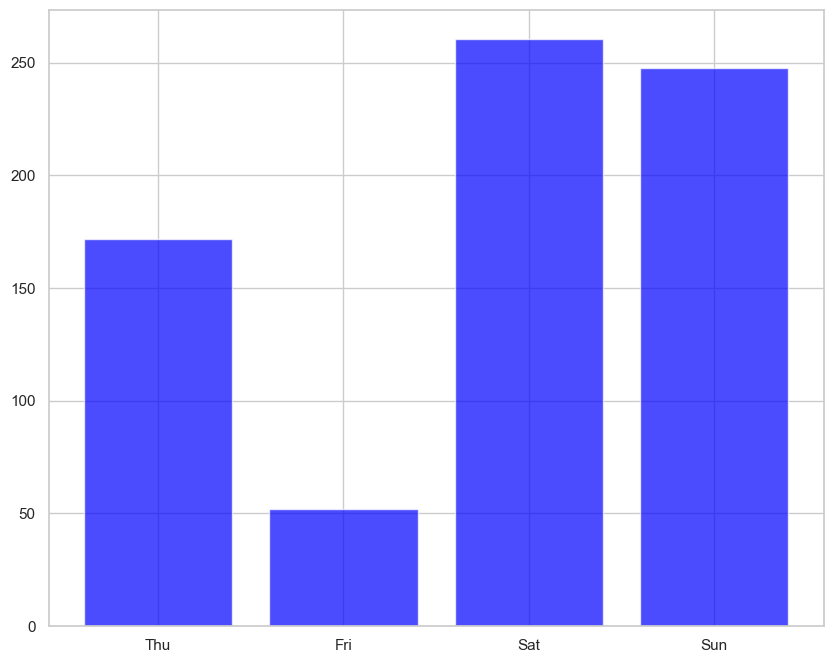

In [65]:
plt.bar(x_label,sum_tip_by_day,
            color="blue",
            alpha=0.7,
            width=0.8)

#### *사실 여기부터 노트북을 바꿔 중간에 조금 날라감..*
 *(Bar Chart Seaborn으로하는거, Pie 차트)* 

# Line 차트

### tips에 가상 시간 컬럼 추가!

In [66]:
sun_tips = tips[tips["day"] == "Sun"]
sun_tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
186,20.90,3.50,Female,Yes,Sun,Dinner,3
187,30.46,2.00,Male,Yes,Sun,Dinner,5
188,18.15,3.50,Female,Yes,Sun,Dinner,3
189,23.10,4.00,Male,Yes,Sun,Dinner,3


In [67]:
import datetime

In [68]:
today = datetime.date.today()
today

datetime.date(2025, 8, 1)

In [69]:
date = []
date.append(datetime.date.today())

for time in range(sun_tips.shape[0]-1):
        today += datetime.timedelta(1)
        date.append(today)

date


[datetime.date(2025, 8, 1),
 datetime.date(2025, 8, 2),
 datetime.date(2025, 8, 3),
 datetime.date(2025, 8, 4),
 datetime.date(2025, 8, 5),
 datetime.date(2025, 8, 6),
 datetime.date(2025, 8, 7),
 datetime.date(2025, 8, 8),
 datetime.date(2025, 8, 9),
 datetime.date(2025, 8, 10),
 datetime.date(2025, 8, 11),
 datetime.date(2025, 8, 12),
 datetime.date(2025, 8, 13),
 datetime.date(2025, 8, 14),
 datetime.date(2025, 8, 15),
 datetime.date(2025, 8, 16),
 datetime.date(2025, 8, 17),
 datetime.date(2025, 8, 18),
 datetime.date(2025, 8, 19),
 datetime.date(2025, 8, 20),
 datetime.date(2025, 8, 21),
 datetime.date(2025, 8, 22),
 datetime.date(2025, 8, 23),
 datetime.date(2025, 8, 24),
 datetime.date(2025, 8, 25),
 datetime.date(2025, 8, 26),
 datetime.date(2025, 8, 27),
 datetime.date(2025, 8, 28),
 datetime.date(2025, 8, 29),
 datetime.date(2025, 8, 30),
 datetime.date(2025, 8, 31),
 datetime.date(2025, 9, 1),
 datetime.date(2025, 9, 2),
 datetime.date(2025, 9, 3),
 datetime.date(2025, 9, 4)

In [70]:
sun_tips["date"] = date
sun_tips

,total_bill,tip,sex,smoker,day,time,size,date
0,16.99,1.01,Female,No,Sun,Dinner,2,2025-08-01
1,10.34,1.66,Male,No,Sun,Dinner,3,2025-08-02
2,21.01,3.50,Male,No,Sun,Dinner,3,2025-08-03
3,23.68,3.31,Male,No,Sun,Dinner,2,2025-08-04
4,24.59,3.61,Female,No,Sun,Dinner,4,2025-08-05
...,...,...,...,...,...,...,...,...
186,20.90,3.50,Female,Yes,Sun,Dinner,3,2025-10-11
187,30.46,2.00,Male,Yes,Sun,Dinner,5,2025-10-12
188,18.15,3.50,Female,Yes,Sun,Dinner,3,2025-10-13
189,23.10,4.00,Male,Yes,Sun,Dinner,3,2025-10-14


## Matplotlib으로 시각화

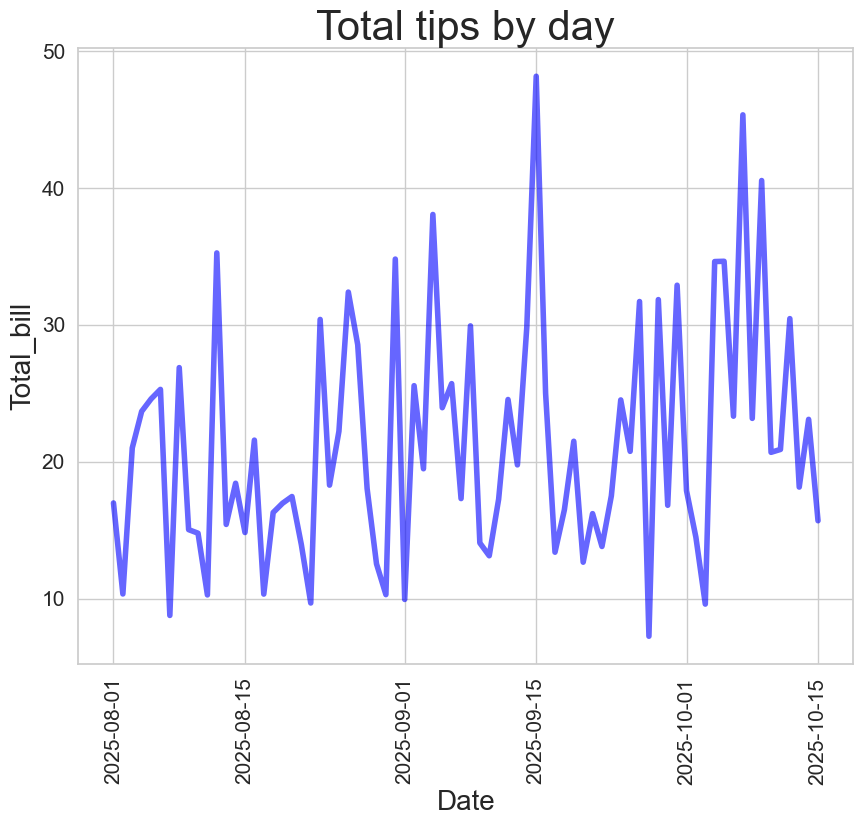

In [71]:
plt.plot(sun_tips["date"], sun_tips["total_bill"],
             linestyle="-",
             linewidth=4,
             color="blue",
             alpha=0.6)
plt.title("Total tips by day", fontsize=30)
plt.xlabel("Date", fontsize=20)
plt.ylabel("Total_bill", fontsize=20)
plt.xticks(rotation=90, fontsize=15)
plt.yticks(fontsize=15)
plt.show()

## Seaborn으로 시각화

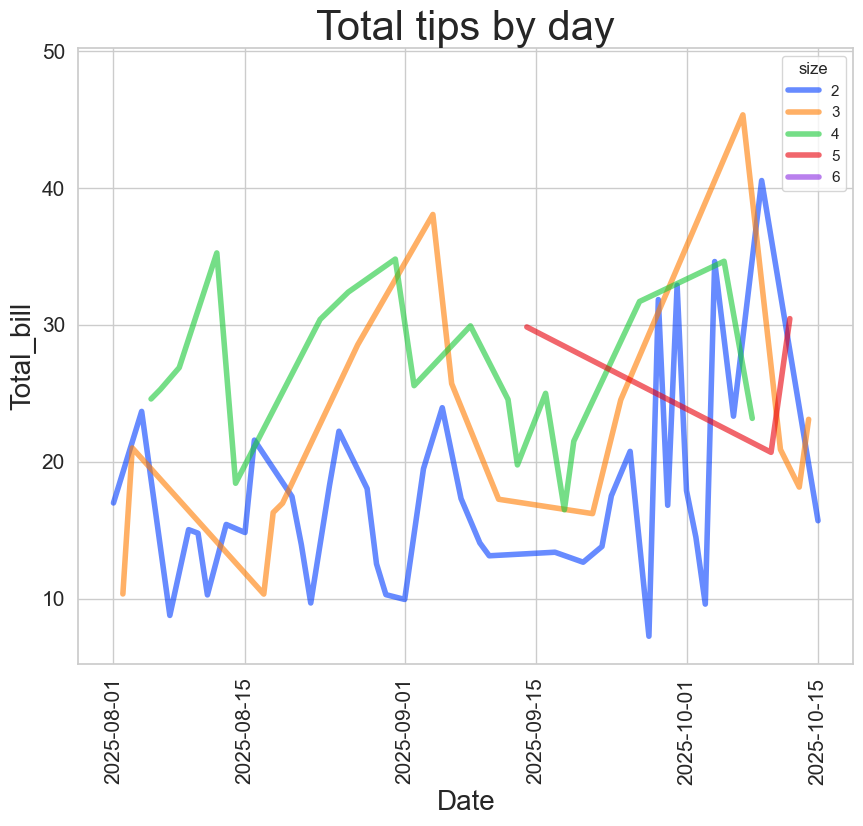

In [72]:
sns.lineplot(data=sun_tips,
                    x="date",
                    y="total_bill",
                    hue="size",
                    linewidth=4,
                    alpha=0.6,
                    palette="bright")
plt.title("Total tips by day", fontsize=30)
plt.xlabel("Date", fontsize=20)
plt.ylabel("Total_bill", fontsize=20)
plt.xticks(rotation=90, fontsize=15)
plt.yticks(fontsize=15)
plt.show()

# Scatter 차트

## Matplotlib으로 시각화

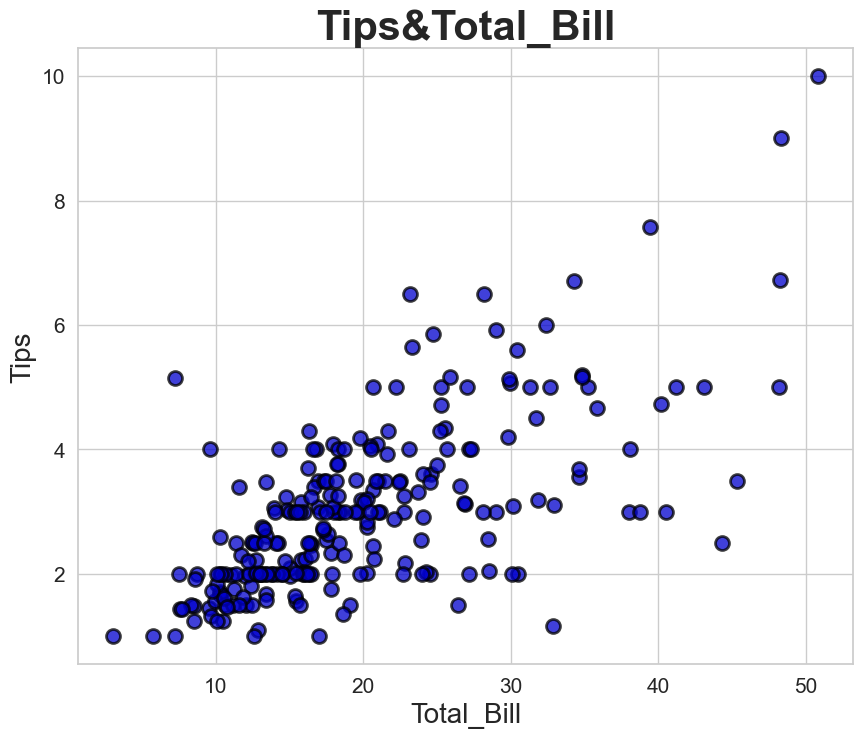

In [73]:
plt.scatter(tips["total_bill"],tips["tip"],
                  color="mediumblue",
                  edgecolor="black",
                  linewidths=2,
                  s=100,
                  alpha=0.75,)
plt.title("Tips&Total_Bill",fontsize=30, fontweight="bold")
plt.xlabel("Total_Bill", fontsize=20)
plt.ylabel("Tips", fontsize=20)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

## Seaborn으로 시각화

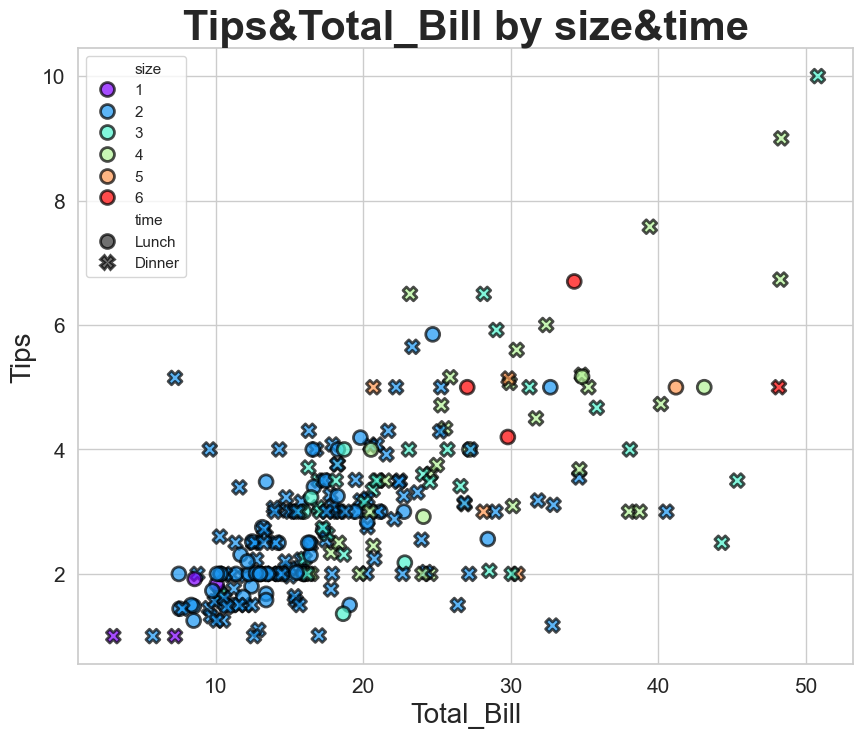

In [74]:
sns.scatterplot(data=tips,
                          x="total_bill",
                          y="tip",
                          color="blue",
                          s=100,
                          alpha=0.7,
                          edgecolor="black",
                          linewidths=2,
                          hue="size",              #색상 구분
                          style="time",            #모양 구분
                        #   size="day",         #크기 구분
                          palette="rainbow")
plt.title("Tips&Total_Bill by size&time",fontsize=30, fontweight="bold")
plt.xlabel("Total_Bill", fontsize=20)
plt.ylabel("Tips", fontsize=20)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

# Heat Map 차트

## Seaborn으로 시각화

In [75]:
tips.corr(numeric_only=True) # 연속형 데이터만 골라서 상관계수 데이터프레임 생성

,total_bill,tip,size
total_bill,1.000000,0.675734,0.598315
tip,0.675734,1.000000,0.489299
size,0.598315,0.489299,1.000000


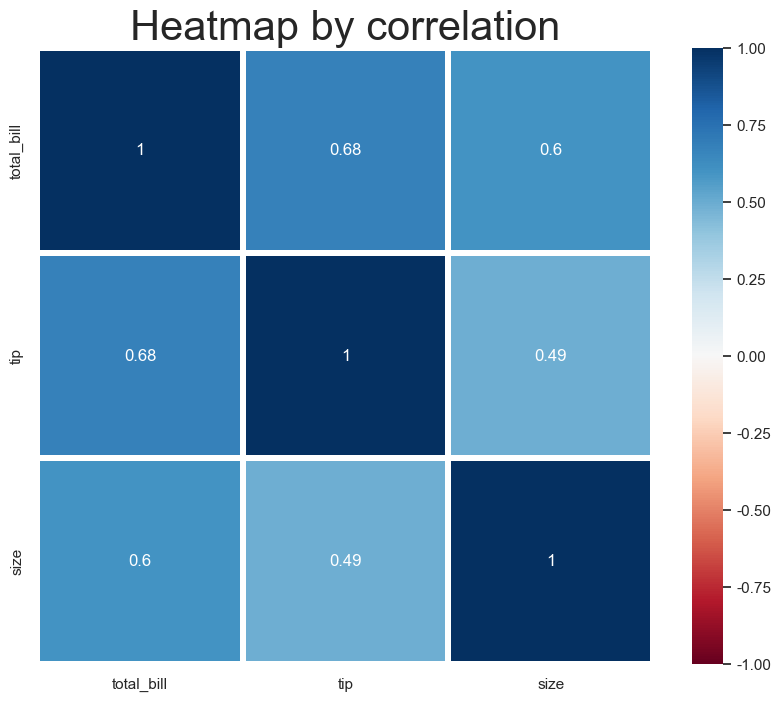

In [76]:
sns.heatmap(tips.corr(numeric_only=True),
                      annot=True, #수 표시 
                      square=True, # 정사각형으로 만들 것인가?
                      vmin=-1, vmax=1, # 최대, 최소값 지정(도수 부분)
                      linewidths=3, # 간격 지정
                      cmap="RdBu" # 컬러맵 지정(RdBu는 높으면 차갑고 낮으면 따뜻한 색감을 줘 좋음 bb)
                      )
plt.title("Heatmap by correlation", fontsize=30)
plt.show()

# Histogram 차트

## Matplotlib으로 시각화

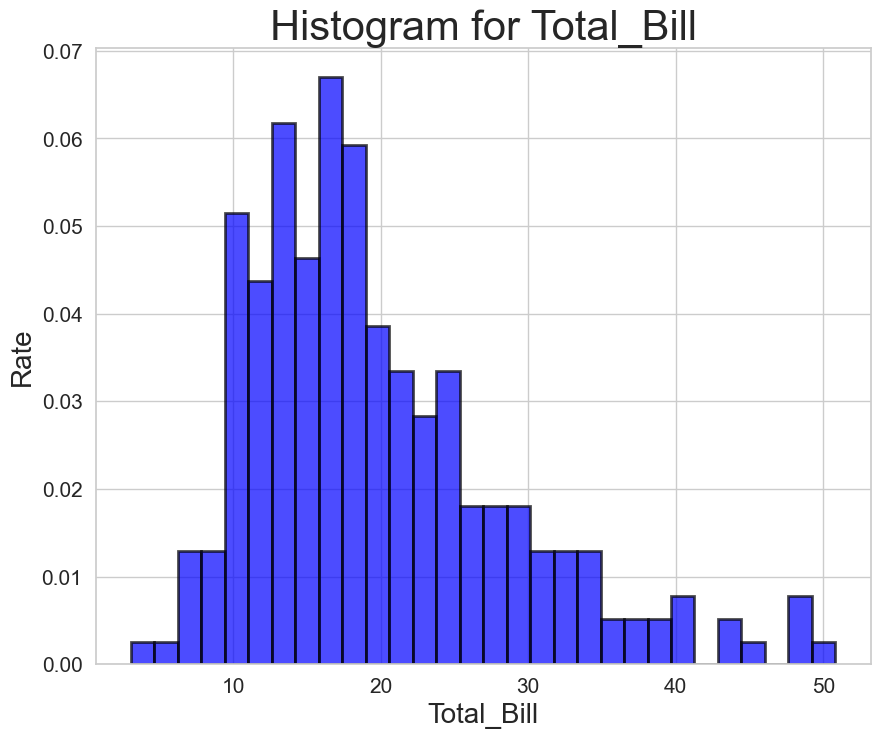

In [77]:
plt.hist(tips["total_bill"],
            bins=30, # 막대의 수 지정
            density=True,
            alpha=0.7,
            color="blue",
            edgecolor = "black",
            linewidth=2) # 비율로 보여줄 것인가?
plt.title("Histogram for Total_Bill", fontsize=30)
plt.xlabel("Total_Bill", fontsize=20)
plt.ylabel("Rate", fontsize=20)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

## Seaborn으로 시각화

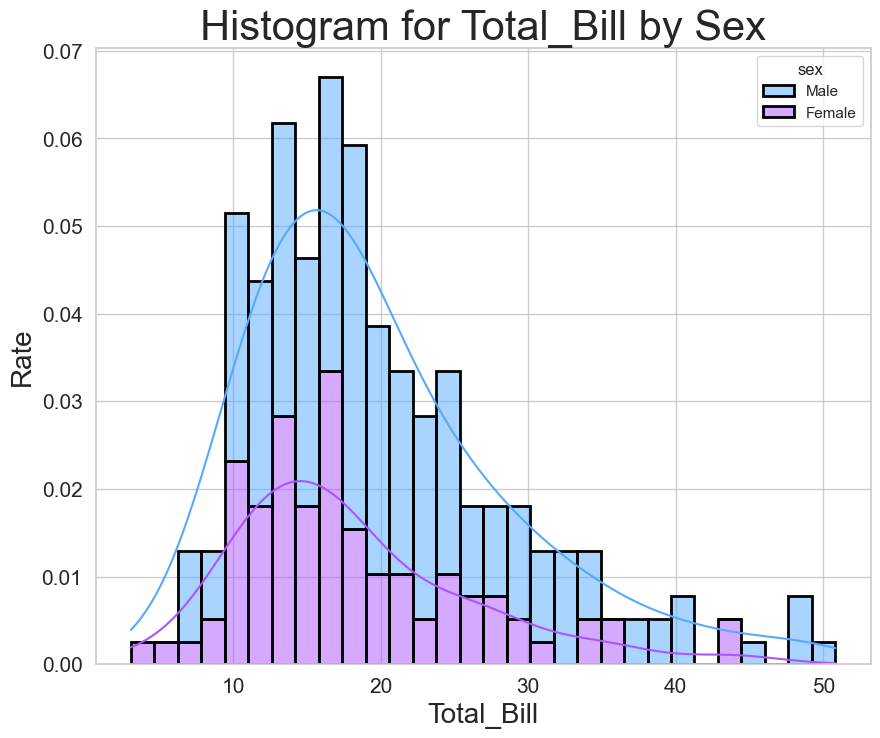

In [102]:
sns.histplot(data=tips,
                    x="total_bill",
                    bins=30, # 막대 개수 지정
                    kde=True, # 선 여부 지정
                    hue="sex", # 크기로 색깔별 분리
                    palette="cool",
                    edgecolor="black",
                    linewidth=2,
                    alpha=0.5,
                    multiple="stack", # 어떤 형식으로 여러 데이터를 표현할지 결정
                    stat="density", # 비율로 보기
                    shrink=1 # 막대 두께 지정
                    )
plt.title("Histogram for Total_Bill by Sex", fontsize=30)
plt.xlabel("Total_Bill", fontsize=20)
plt.ylabel("Rate", fontsize=20)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

# Box 차트
### 이걸 왜함ㅋㅋ 어따씀?ㅋㅋㅋㅋ

## Matplotlib으로 시각화

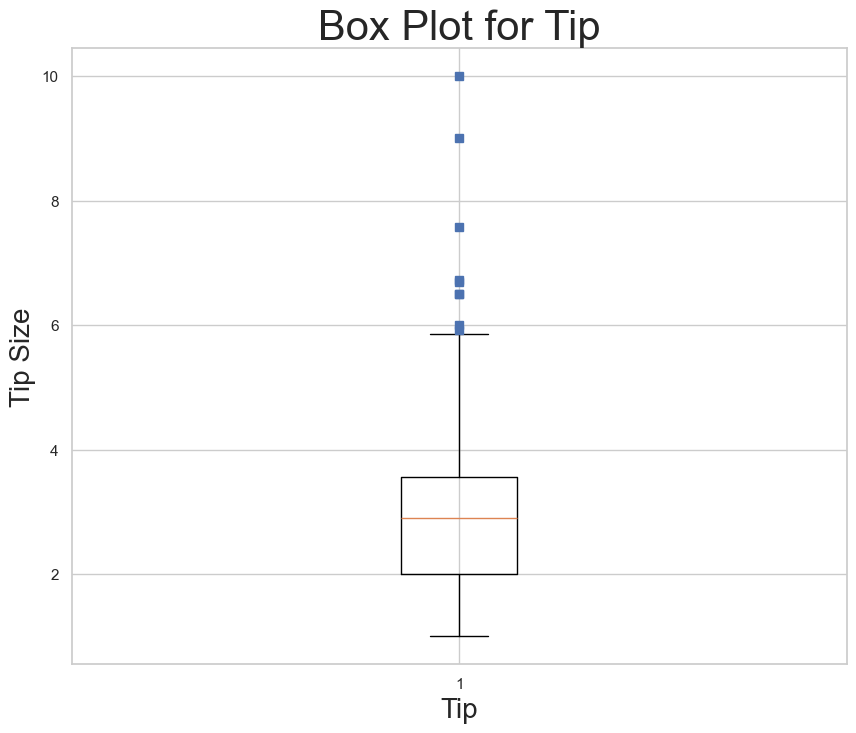

In [113]:
plt.boxplot(tips["tip"],
            sym="bs")
plt.title("Box Plot for Tip", fontsize=30)
plt.xlabel("Tip", fontsize=20)
plt.ylabel("Tip Size", fontsize=20)
plt.show()

## Seaborn으로 시각화

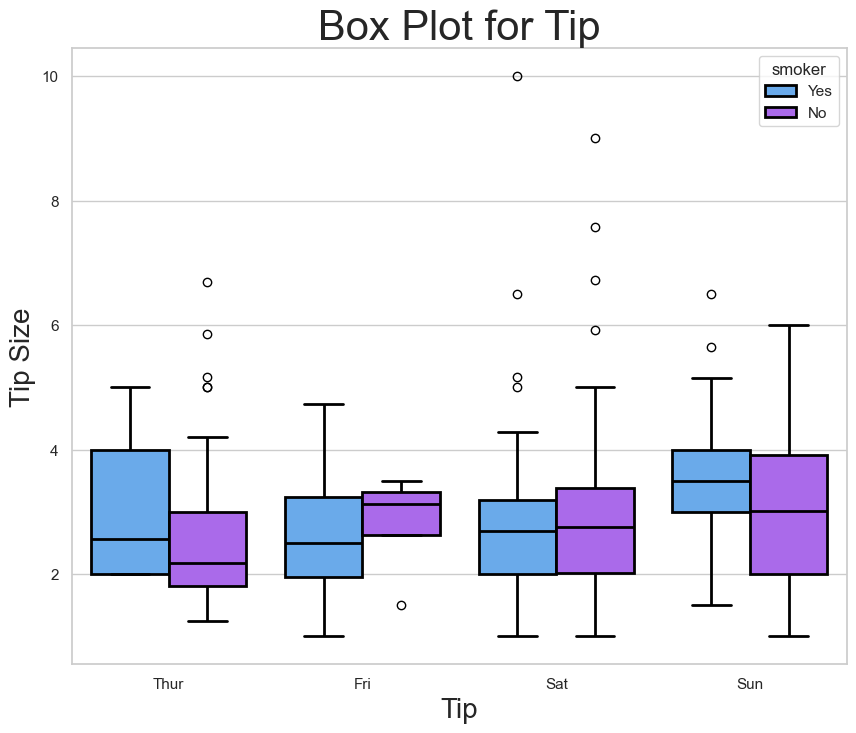

In [122]:
sns.boxplot(data=tips,
                    x="day",
                    y="tip",
                    hue="smoker",
                    palette="cool",
                    linewidth=2,
                    linecolor="black")
plt.title("Box Plot for Tip", fontsize=30)
plt.xlabel("Tip", fontsize=20)
plt.ylabel("Tip Size", fontsize=20)
plt.show()